# Modelo de Monod em Python

Este caderno apresenta uma implementação didática do modelo de Monod para cinética microbiana, com aplicações em reator batelada e quimiostato. O objetivo é ilustrar os conceitos fundamentais, a solução numérica das equações diferenciais e a influência dos parâmetros.

## 1. Introdução

O modelo de Monod descreve a taxa de crescimento específico de microrganismos em função da concentração de um substrato limitante. É amplamente utilizado em engenharia ambiental para modelar processos como tratamento de águas residuais, biorremediação e digestão anaeróbia.

Neste caderno, vamos:
- Definir as equações do modelo.
- Implementar a solução numérica para um reator batelada.
- Visualizar a evolução temporal da biomassa e substrato.
- Explorar a influência dos parâmetros cinéticos.
- Estender o modelo para um reator contínuo (quimiostato).

## 2. Equações do Modelo de Monod

A taxa específica de crescimento microbiano é dada por:

$$
\mu = \mu_{\text{max}} \frac{S}{K_s + S}
$$

onde:
- $\mu$ = taxa específica de crescimento (h⁻¹)
- $\mu_{\text{max}}$ = taxa máxima de crescimento (h⁻¹)
- $S$ = concentração de substrato limitante (mg/L)
- $K_s$ = constante de meia-saturação (mg/L) - concentração de substrato na qual $\mu = \mu_{\text{max}}/2$

Em um reator batelada, as equações de balanço de massa para biomassa ($X$) e substrato ($S$) são:

$$
\frac{dX}{dt} = \mu X = \mu_{\text{max}} \frac{S}{K_s + S} X
$$

$$
\frac{dS}{dt} = -\frac{1}{Y} \mu X = -\frac{1}{Y} \mu_{\text{max}} \frac{S}{K_s + S} X
$$

onde $Y$ é o coeficiente de rendimento (mg biomassa / mg substrato consumido).

## 3. Implementação em Python

Vamos usar as bibliotecas `numpy`, `scipy.integrate` e `matplotlib`.

In [ ]:
# Importação das bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Configuração dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 4. Definição da função de derivadas

In [ ]:
def monod_batch(t: float, y: np.ndarray, mumax: float, Ks: float, Y: float) -> list[float]:
    """
    Calcula dX/dt e dS/dt para o modelo de Monod em reator batelada.

    Convenção de unidades usada neste caderno:
    - X: concentração de biomassa [mgX/L]
    - S: concentração de substrato [mgS/L]
    - mumax: taxa máxima de crescimento [h^-1]
    - Ks: constante de meia-saturação [mgS/L]
    - Y: rendimento celular [mgX/mgS]

    Parâmetros
    ----------
    t : float
        Tempo [h]. Não entra explicitamente na cinética, mas é exigido por
        solve_ivp.
    y : array-like de tamanho 2
        Vetor de estado [X, S], com X em [mgX/L] e S em [mgS/L].
    mumax : float
        Taxa máxima de crescimento específico [h^-1].
    Ks : float
        Constante de meia-saturação [mgS/L].
    Y : float
        Coeficiente de rendimento biomassa/substrato [mgX/mgS].

    Devolve
    -------
    list[float]
        [dXdt, dSdt], com:
        - dXdt em [mgX/L/h]
        - dSdt em [mgS/L/h]

    Observação
    ----------
    Para manter coerência dimensional, X e S devem seguir a base de massa
    indicada por Y (neste caso, mgX e mgS).
    """
    X, S = y
    # Evitar divisão por zero ou valores negativos (S pode ser muito pequeno)
    if S <= 0:
        dXdt = 0.0
        dSdt = 0.0
    else:
        mu = mumax * S / (Ks + S)
        dXdt = mu * X
        dSdt = - (1/Y) * mu * X
    return [dXdt, dSdt]

## 5. Simulação em batelada

Escolhemos parâmetros típicos para um sistema aeróbio de tratamento de esgoto:
- $\mu_{\text{max}} = 0.5\ \text{h}^{-1}$
- $K_s = 50\ \text{mg/L}$
- $Y = 0.6\ \text{mgX/mgS}$
- Condições iniciais: $X_0 = 10\ \text{mg/L}$, $S_0 = 500\ \text{mg/L}$
- Tempo de simulação: 48 horas

In [8]:
# Parâmetros
mumax = 0.5      # h^{-1}
Ks = 50.0        # mg/L
Y = 0.6          # mgX/mgS
X0 = 10.0        # mg/L
S0 = 500.0       # mg/L
t_span = (0, 48) # horas
t_eval = np.linspace(0, 48, 200)  # pontos para saída

# Resolver EDO
sol = solve_ivp(monod_batch, t_span, [X0, S0], args=(mumax, Ks, Y),
                t_eval=t_eval, method='RK45')

# Extrair resultados
t = sol.t
X = sol.y[0]
S = sol.y[1]

# Verificar se a solução foi bem-sucedida
if not sol.success:
    print("A integração falhou:", sol.message)

## 6. Visualização dos resultados

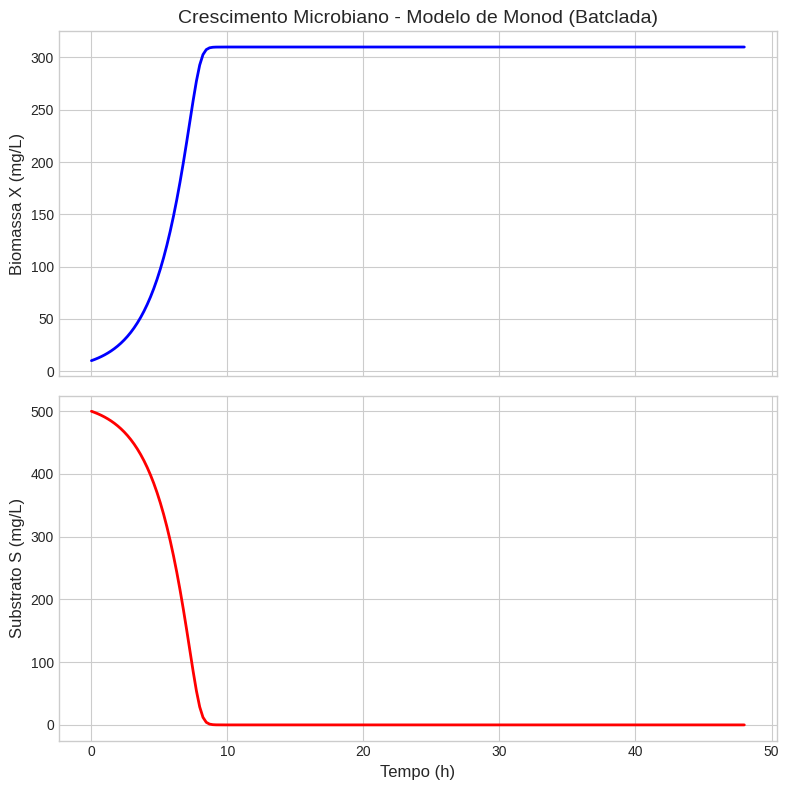

In [4]:
# Gráfico da evolução temporal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

ax1.plot(t, X, 'b-', linewidth=2)
ax1.set_ylabel('Biomassa X (mg/L)', fontsize=12)
ax1.grid(True)
ax1.set_title('Crescimento Microbiano - Modelo de Monod (Batclada)', fontsize=14)

ax2.plot(t, S, 'r-', linewidth=2)
ax2.set_xlabel('Tempo (h)', fontsize=12)
ax2.set_ylabel('Substrato S (mg/L)', fontsize=12)
ax2.grid(True)

plt.tight_layout()
plt.show()

**Interpretação:** A biomassa cresce exponencialmente enquanto o substrato é abundante, depois a taxa de crescimento diminui à medida que o substrato se esgota, até que a biomassa atinge um platô quando o substrato é completamente consumido.

## 7. Efeito da variação de parâmetros

Vamos analisar como $K_s$ e $\mu_{\text{max}}$ afetam a dinâmica.

### 7.1. Variação de $K_s$

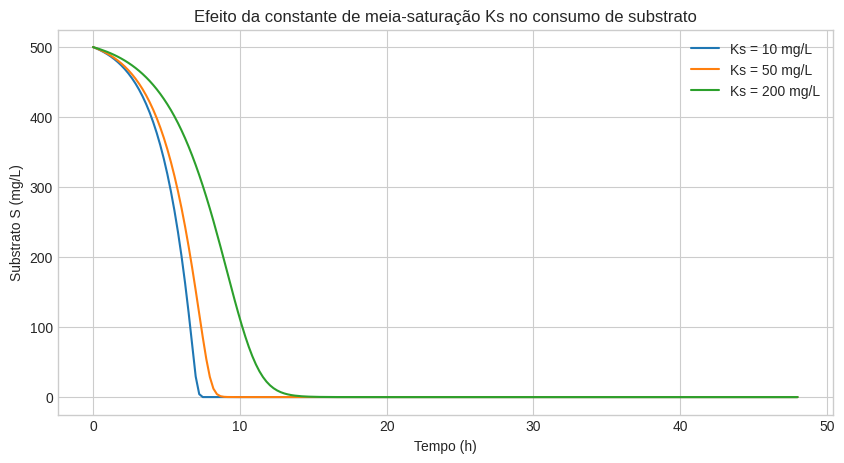

In [5]:
Ks_values = [10, 50, 200]
plt.figure(figsize=(10, 5))

for Ks_val in Ks_values:
    sol = solve_ivp(monod_batch, t_span, [X0, S0], args=(mumax, Ks_val, Y),
                    t_eval=t_eval, method='RK45')
    plt.plot(sol.t, sol.y[1], label=f'Ks = {Ks_val} mg/L')  # substrato

plt.xlabel('Tempo (h)')
plt.ylabel('Substrato S (mg/L)')
plt.title('Efeito da constante de meia-saturação Ks no consumo de substrato')
plt.legend()
plt.grid(True)
plt.show()

**Interpretação:** Quanto menor $K_s$, mais rapidamente o substrato é consumido (maior afinidade dos microrganismos pelo substrato).

### 7.2. Variação de $\mu_{\text{max}}$

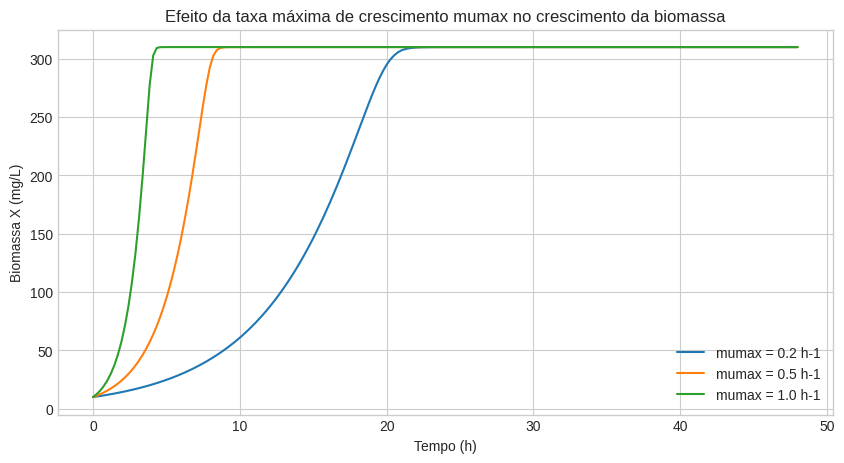

In [6]:
mumax_values = [0.2, 0.5, 1.0]
plt.figure(figsize=(10, 5))

for mumax_val in mumax_values:
    sol = solve_ivp(monod_batch, t_span, [X0, S0], args=(mumax_val, Ks, Y),
                    t_eval=t_eval, method='RK45')
    plt.plot(sol.t, sol.y[0], label=f'mumax = {mumax_val} h-1')  # biomassa

plt.xlabel('Tempo (h)')
plt.ylabel('Biomassa X (mg/L)')
plt.title('Efeito da taxa máxima de crescimento mumax no crescimento da biomassa')
plt.legend()
plt.grid(True)
plt.show()

**Interpretação:** Maior $\mu_{\text{max}}$ acelera o crescimento e antecipa o esgotamento do substrato.

## 8. Análise de métodos numéricos

O sistema de Monod é não linear, mas geralmente não é rígido (stiff) para parâmetros típicos. No entanto, se o coeficiente de rendimento for muito pequeno (ex.: $Y = 0.01$), as escalas de tempo de crescimento e consumo podem se tornar muito diferentes, exigindo métodos implícitos.

Vamos comparar o método explícito de Euler (implementado manualmente) com o `solve_ivp` adaptativo para um caso potencialmente rígido.

In [7]:
# Implementação do método de Euler explícito
def euler_monod(f, y0, t_span, dt, args):
    t0, tf = t_span
    t = np.arange(t0, tf+dt, dt)
    n = len(t)
    y = np.zeros((n, len(y0)))
    y[0] = y0
    for i in range(n-1):
        y[i+1] = y[i] + dt * f(t[i], y[i], *args)
    return t, y

# Parâmetros para caso rígido (Y muito pequeno)
mumax_stiff = 0.5
Ks_stiff = 50
Y_stiff = 0.01
X0_stiff = 10
S0_stiff = 500
t_span_stiff = (0, 48)
dt_euler = 0.01  # passo pequeno para evitar instabilidade

# Euler
t_euler, y_euler = euler_monod(monod_batch, [X0_stiff, S0_stiff], t_span_stiff, dt_euler, 
                                (mumax_stiff, Ks_stiff, Y_stiff))

# solve_ivp com método RK45 (adaptativo)
sol_stiff = solve_ivp(monod_batch, t_span_stiff, [X0_stiff, S0_stiff], 
                      args=(mumax_stiff, Ks_stiff, Y_stiff),
                      method='RK45', t_eval=t_euler)  # avaliar nos mesmos tempos para comparar

# Gráfico comparativo
plt.figure(figsize=(10,5))
plt.plot(t_euler, y_euler[:,0], 'b--', label='Euler (dt=0.01)')
plt.plot(sol_stiff.t, sol_stiff.y[0], 'r-', label='solve_ivp RK45')
plt.xlabel('Tempo (h)')
plt.ylabel('Biomassa X (mg/L)')
plt.title('Comparação Euler vs RK45 para caso com Y pequeno')
plt.legend()
plt.grid(True)
plt.show()

TypeError: can't multiply sequence by non-int of type 'float'

Se Euler explícito exigir um passo muito pequeno para estabilidade, o método adaptativo do `solve_ivp` será mais eficiente. Para problemas rígidos, pode-se usar `method='Radau'` ou `'BDF'` no lugar de `'RK45'`.

## 9. Extensão para reator contínuo (quimiostato)

Em um quimiostato (reator de mistura completa com alimentação contínua e vazão de saída), as equações tornam-se:

$$
\frac{dX}{dt} = \mu X - D X
$$
$$
\frac{dS}{dt} = D (S_{in} - S) - \frac{1}{Y} \mu X
$$

onde $D = Q/V$ é a taxa de diluição (h⁻¹) e $S_{in}$ é a concentração de substrato na alimentação.

No estado estacionário, as derivadas são zero, levando a um sistema de equações algébricas. Da primeira equação: ou $X=0$ (washout) ou $\mu = D$. Usando a expressão de Monod:

$$
D = \mu_{\text{max}} \frac{S}{K_s + S} \quad \Rightarrow \quad S = \frac{D K_s}{\mu_{\text{max}} - D}
$$

Substituindo na segunda equação estacionária:

$$
D (S_{in} - S) - \frac{1}{Y} \mu X = 0 \quad \Rightarrow \quad X = Y (S_{in} - S)
$$

Essas expressões são válidas para $D < \mu_{\text{max}}$. Para $D \ge \mu_{\text{max}}$, ocorre washout ($X=0, S=S_{in}$).

Vamos implementar uma função que calcula o estado estacionário para um dado $D$.

In [ ]:
def steady_state_chemostat(D, Sin, mumax, Ks, Y):
    """
    Devolve as concentrações de estado estacionário (X, S) para um quimiostato.
    Se D >= mumax, devolve washout (X=0, S=Sin).
    """
    if D >= mumax:
        return 0.0, Sin
    else:
        S = D * Ks / (mumax - D)
        X = Y * (Sin - S)
        # Garantir que não sejam negativos (por precisão numérica)
        X = max(X, 0.0)
        S = max(S, 0.0)
        return X, S

# Parâmetros do quimiostato
Sin = 1000.0      # mg/L
D_vals = np.linspace(0, 0.7, 50)  # taxa de diluição (mumax=0.5)

X_ss = []
S_ss = []
for D in D_vals:
    X, S = steady_state_chemostat(D, Sin, mumax, Ks, Y)
    X_ss.append(X)
    S_ss.append(S)

# Gráfico do estado estacionário em função de D
fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:red'
ax1.set_xlabel('Taxa de diluição D (h⁻¹)')
ax1.set_ylabel('Substrato S (mg/L)', color=color)
ax1.plot(D_vals, S_ss, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(mumax, color='gray', linestyle='--', label=f'mumax={mumax} h⁻¹')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Biomassa X (mg/L)', color=color)
ax2.plot(D_vals, X_ss, color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Estado estacionário do quimiostato em função da diluição')
fig.tight_layout()
plt.show()

**Interpretação:** Para baixas diluições, a biomassa é alta e o substrato residual é baixo. À medida que $D$ aumenta, a biomassa atinge um máximo e depois cai, até que em $D = \mu_{\text{max}}$ ocorre o washout completo.

## 10. Conclusão

Neste caderno, exploramos o modelo de Monod, sua implementação numérica em Python e aplicações em batelada e contínuo. Discutimos a influência dos parâmetros e a necessidade de métodos numéricos adequados. Este conhecimento é fundamental para modelagem de processos biológicos em engenharia ambiental e pode ser estendido para modelos mais complexos (Andrews, Contois, etc.).

**Observações finais:**
- Para problemas reais, pode ser necessário ajustar parâmetros a partir de dados experimentais (etapa de estimação).
- A escolha do método de integração deve considerar a rigidez do sistema; `solve_ivp` oferece opções como `BDF` e `Radau` para esses casos.
- O código aqui apresentado é didático; para simulações mais robustas, considere usar pacotes especializados (ex.: `bioptim`, `AMIGO`).